In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

seed = 52

CWD = os.getcwd()
DATA_PATH = os.path.join(CWD, '10X_multiome_mouse_brain.loom')
CELLANNO_PATH = os.path.join(CWD, 'cell_annotations.tsv')

In [3]:
# Load data
adata =sc.read_loom(DATA_PATH)
adata.var_names_make_unique()
adata.obs_names = [obs.split(':')[1][:-1] + '-1' for obs in adata.obs_names]

In [4]:
# Load cell annotations from Multivelo 
cell_annot = pd.read_csv(CELLANNO_PATH, sep='\t', index_col=0)
adata = adata[cell_annot.index,:]
adata.obs['celltype'] = cell_annot['celltype']

In [5]:
# Compute quality control metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'],log1p=False, percent_top=None, inplace=True)

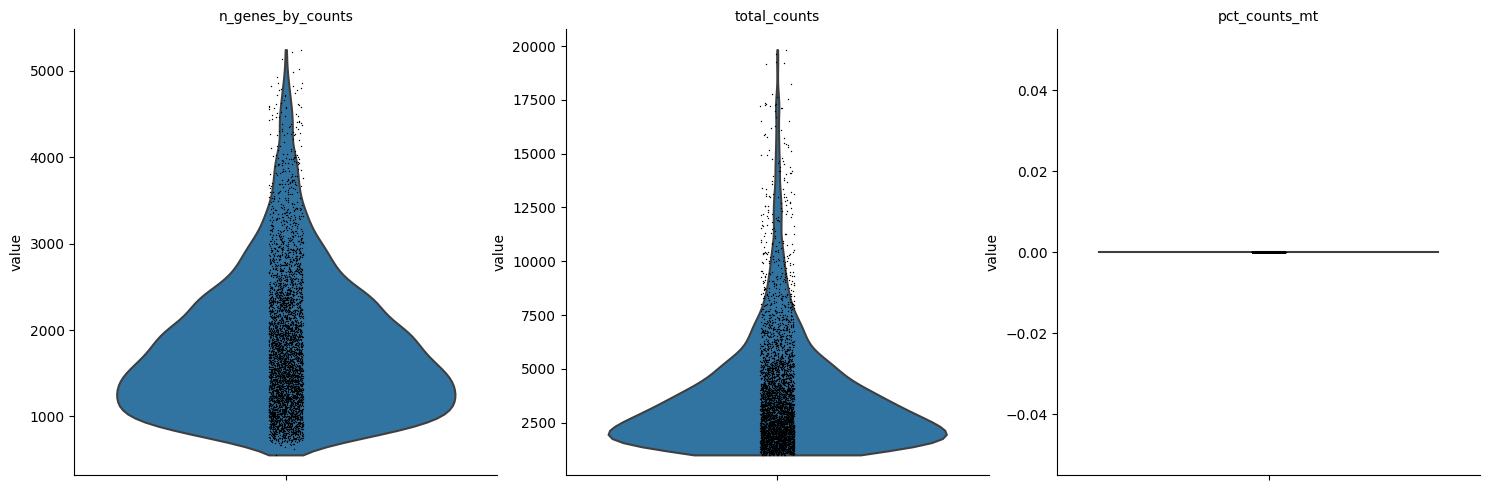

In [6]:
# Plot quality control metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts',  'pct_counts_mt'], jitter = 0.04, 
             multi_panel= True, save = "QC_loom.png")

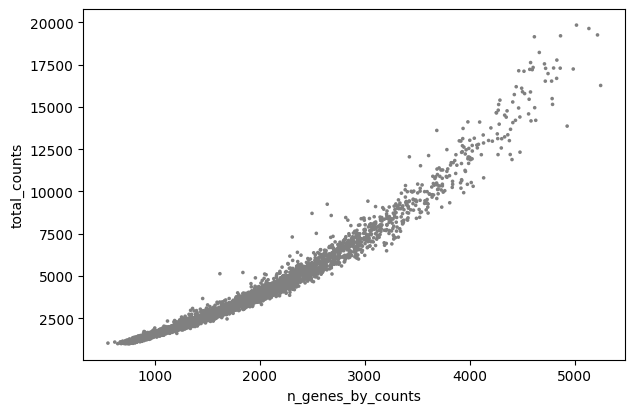

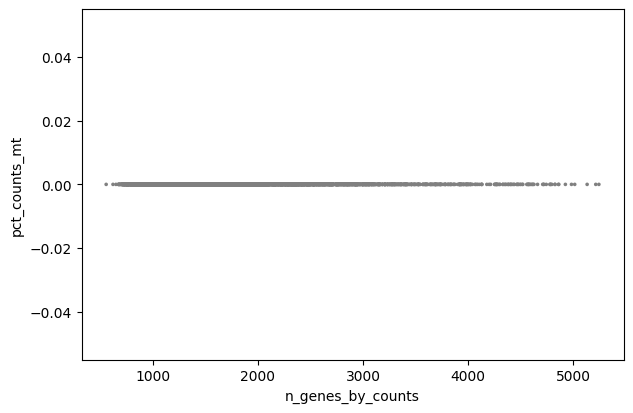

In [7]:
sc.pl.scatter(adata, x='n_genes_by_counts', y='total_counts', save = "QC_totalCounts_loom.png")
sc.pl.scatter(adata, x='n_genes_by_counts', y='pct_counts_mt', save = "QC_mtPerc_loom.png")

In [8]:
# Filtering cells
lower, upper = np.percentile(adata.obs.n_genes_by_counts, [2, 98]).astype(int)
print(f'Retaining cells with {lower} < n_genes_by_counts < {upper}')
adata = adata[adata.obs.n_genes_by_counts>lower]
adata = adata[adata.obs.n_genes_by_counts<upper]

Retaining cells with 767 < n_genes_by_counts < 3979


In [9]:
# Filtering + normalization (of each cell by total counts over all genes) + log transform
# We compute highly variable genes but do not subset for them 
# Min shared counts is the minimum number of counts in both spliced and unspliced required for a gene to pass filtering
scv.pp.filter_and_normalize(adata, min_shared_counts=10, n_top_genes=2000, subset_highly_variable=False)
# Filtering somma i unspliced e spliced nei geni dove entrambi sono > 0 e trattiene quei geni che sono > 10  
# Normalize_per_cell normalizza sia X, unspliced e spliced
# X = log(X+1)

Filtered out 21769 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\preprocessing\utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [10]:
sc.pp.scale(adata)
sc.pp.scale(adata, layer='spliced')
sc.pp.scale(adata, layer='unspliced')

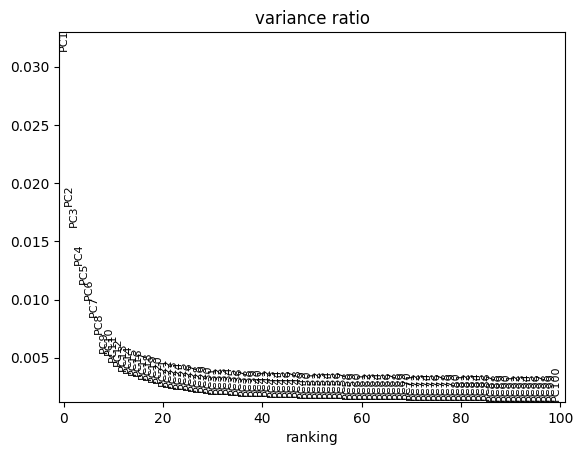

In [11]:
# PCA
sc.tl.pca(adata, n_comps = 100, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=100, save='_loom.png')

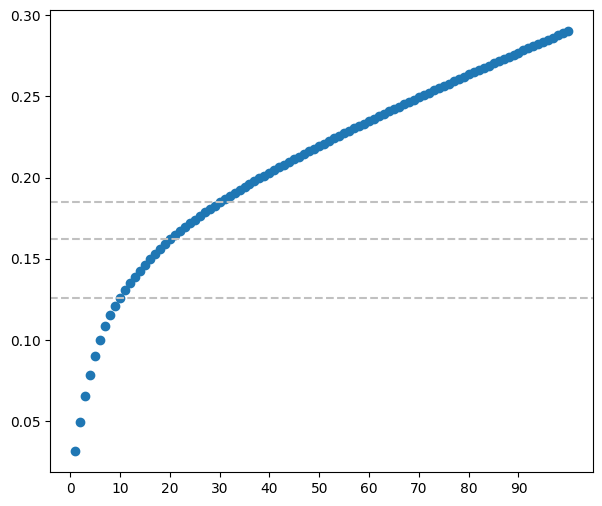

In [12]:
# Explained variance plot
cumulative_variance_ratio = np.cumsum(adata.uns['pca']['variance_ratio'])
fig, ax = plt.subplots(figsize=(7, 6))
plt.scatter(range(1,101), cumulative_variance_ratio, )
plt.axhline(cumulative_variance_ratio[9], color='silver', linestyle='dashed') # Variance explained by first 10 components
plt.axhline(cumulative_variance_ratio[19], color='silver', linestyle='dashed') # Variance explained by first 20 components
plt.axhline(cumulative_variance_ratio[29], color='silver', linestyle='dashed') # Variance explained by first 30 components
ax.set_xticks(range(0, 100, 10))
plt.savefig('figures/pcs_explained_variance_loom.png')

In [13]:
# Saving file
adata.write_h5ad(os.path.join(CWD, "10xMouse_loom_preprocessed.h5ad"))

In [16]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30, random_state = seed)
sc.tl.umap(adata, random_state=seed)

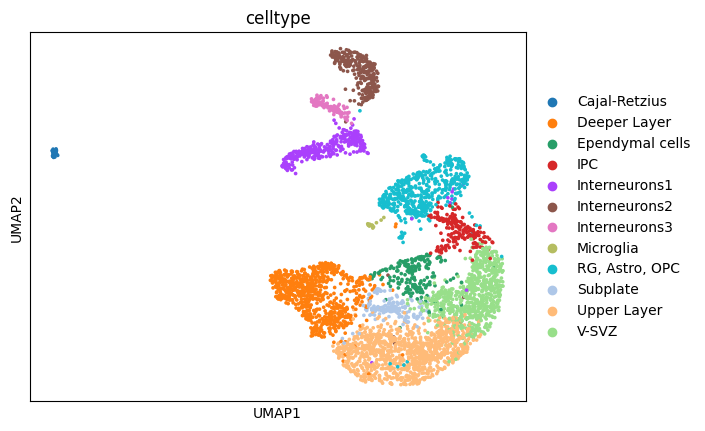

In [17]:
sc.pl.umap(adata, color=['celltype'], save='_cellannotations_loom.png')

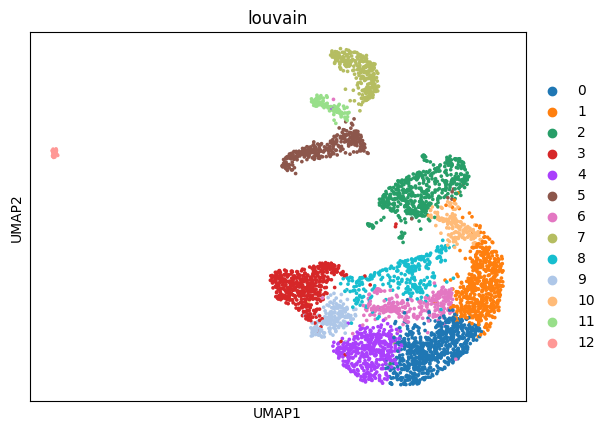

In [18]:
# Compute Louvein clustering and plot
sc.tl.louvain(adata, random_state=seed)
sc.pl.umap(adata, color='louvain')

In [19]:
# Saving 
adata.write_h5ad(os.path.join(CWD, '10XMouse_Loom_clustered.h5ad'))

# Velocities using Multivelo cell annotations - dynamical model

In [20]:
adata = sc.read_h5ad(os.path.join(CWD, '10xMouse_loom_preprocessed.h5ad'))
# Filter for lineages towards neurons and astrocytes
adata = adata[adata.obs['celltype'].isin(['RG, Astro, OPC', 
                                                     'IPC', 
                                                     'V-SVZ', 
                                                      'Upper Layer', 
                                                      'Deeper Layer', 
                                                      'Ependymal cells', 
                                                      'Subplate'])]

In [21]:
# ScVelo moments computation
# 1. computes PCA -> HYPER PARAMETER PCs =  NUMBER OF PRINCIPAL COMPONENTS
# 2. coputes neighbor graph based on Euclidean distances -> HYPERPARAMETER K = NUMBER OF NEIGHBORS
# 3. compute first and second order moments (means and uncentered variances) for each cell across its neighbors
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata, random_state=seed)

computing neighbors
    finished (0:00:01) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:19) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [22]:
# Recovers full splicing kinetics 
scv.tl.recover_dynamics(adata, n_jobs=-1)

recovering dynamics (using 8/8 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:08:30) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [23]:
scv.tl.velocity(adata, mode='dynamical')
# Fits velocities 
scv.tl.velocity_graph(adata, n_jobs=-1)
# Computes transition probability matrix between cells (si, sj are in opposite directions therefore pi=-1, si, sj are in concordant directions pi = 1 and si sj are in 
# orthogonal directions pi= 0)  -> measure in directionality concordance between a cell and its neighbors

computing velocities
    finished (0:00:06) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/8 cores)
    finished (0:00:12) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_cellannotation_scVelo_velocity_dyn.png


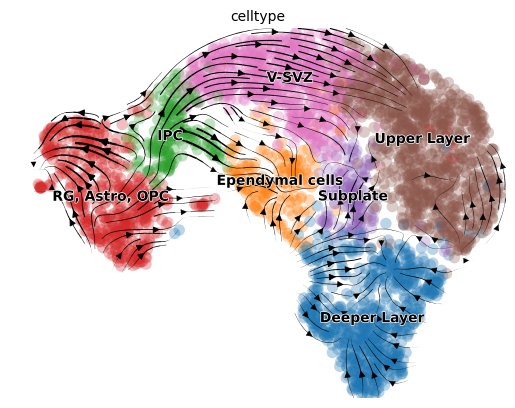

In [24]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color='celltype', save= 'cellannotation_scVelo_velocity_dyn.png')

computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:04) --> added 
    'latent_time', shared time (adata.obs)
saving figure to file ./figures/scvelo_cellannotation_scVelo_latentTime_dyn.png


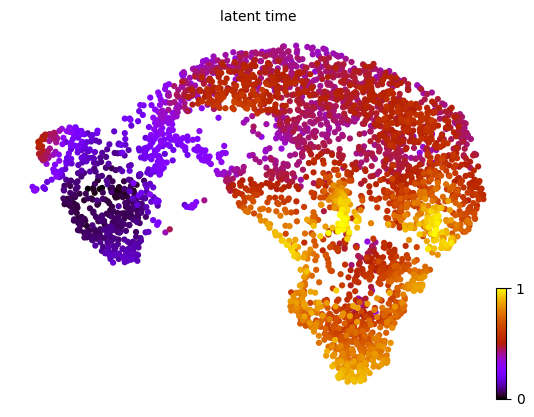

In [25]:
# Compute latent time (cell's internal clock)
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=80, save='cellannotation_scVelo_latentTime_dyn.png')

In [26]:
# Saving file
adata.write_h5ad(os.path.join(CWD, "10xMouse_velocity_dynamical.h5ad"))

# Velocities using Multivelo cell annotations - steady state model 

In [27]:
adata = sc.read_h5ad(os.path.join(CWD, '10xMouse_loom_preprocessed.h5ad'))
# Filter for lineages towards neurons and astrocytes
adata = adata[adata.obs['celltype'].isin(['RG, Astro, OPC', 
                                                     'IPC', 
                                                     'V-SVZ', 
                                                      'Upper Layer', 
                                                      'Deeper Layer', 
                                                      'Ependymal cells', 
                                                      'Subplate'])]

In [28]:
# ScVelo moments computation
# 1. computes PCA -> HYPER PARAMETER PCs =  NUMBER OF PRINCIPAL COMPONENTS
# 2. coputes neighbor graph based on Euclidean distances -> HYPERPARAMETER K = NUMBER OF NEIGHBORS
# 3. compute first and second order moments (means and uncentered variances) for each cell across its neighbors
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata, random_state=seed)

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:10) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [29]:
scv.tl.velocity(adata)
# Fits velocities 
scv.tl.velocity_graph(adata, n_jobs=-1)
# Computes transitoon probability matrix between cells (si, sj are in opposite directions therefore pi=-1, si, sj are in concordant directions pi = 1 and si sj are in 
# orthogonal directions pi= 0)  -> measure in directionality concordance between a cell and its neighbors

computing velocities
    finished (0:00:05) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/8 cores)
    finished (0:00:14) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_cellannotation_scVelo_velocity_steady.png


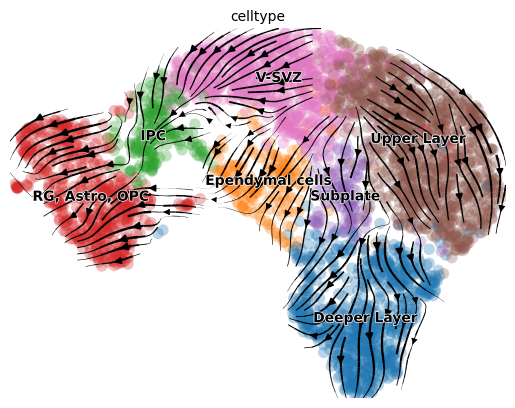

In [30]:
scv.pl.velocity_embedding_stream(adata, basis='umap', color='celltype', save= 'cellannotation_scVelo_velocity_steady.png')

In [32]:
# Saving file
adata.write_h5ad(os.path.join(CWD, "10xMouse_velocity_steady.h5ad"))